# Model Building with Random Under-Sampling (RUS) - Fraud Detection

This notebook implements and evaluates machine learning models using Random Under-Sampling (RUS) to address the class imbalance in the fraud detection dataset.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
)


# reference classifier
from sklearn.dummy import DummyClassifier

# linear models study
from sklearn.linear_model import LogisticRegression

# tree models study
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from xgboost import plot_importance

# SVM study
from sklearn.svm import SVC

# kNN study
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from src.helpers import dataframe_coefficients
from src.config import PROCESSED_DATA
from src.graphics import plot_compare_model_metrics, plot_coefficients
from src.models_rus import RANDOM_STATE
from src.models_rus import (
    grid_search_cv_classifier,
    train_and_validate_classification_model,
    organize_results,
)

sns.set_theme(palette="bright")

In [3]:
df = pd.read_parquet(PROCESSED_DATA)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V23,V24,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.403993,0.251412,-0.018307,-0.110474,0.066928,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.145783,-0.069083,-0.225775,0.101288,-0.339846,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.232622,-0.208038,-0.108300,-0.190321,-1.175575,-0.221929,0.062723,0.061458,123.50,0
3,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.803487,0.408542,-0.009431,-0.137458,0.141267,0.502292,0.219422,0.215153,69.99,0
4,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.033194,0.084968,-0.208254,-0.026398,-0.371427,0.105915,0.253844,0.081080,3.67,0


In [4]:
min_max_columns = ["Time"]

power_transformer_columns = ["Amount"]

target = ["Class"]

robust_scaler_columns = [
    column for column in df.columns if column not in (
        min_max_columns + power_transformer_columns + target
    )
]

robust_scaler_columns

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V23',
 'V24',
 'V26',
 'V27',
 'V28']

In [5]:
X = df.drop(columns=target)
y = df[target].values.ravel()

In [6]:
preprocessing = ColumnTransformer(
    transformers=[
        ("min_max", MinMaxScaler(), min_max_columns),
        ("robust", RobustScaler(), robust_scaler_columns),
        ("power_transform", PowerTransformer(), power_transformer_columns),
    ]
)

In [7]:
# scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]
# scale_pos_weight

In [8]:
classifiers = {
    "DummyClassifier": {
        "preprocessor": None,
        "classifier": DummyClassifier(strategy="stratified"),
    },
    "LogisticRegression": {
        "preprocessor": preprocessing,
        "classifier": LogisticRegression(class_weight="balanced"),
    },
    "DecisionTreeClassifier": {
        "preprocessor": None,
        "classifier": DecisionTreeClassifier(class_weight="balanced"),
    },
    "LGBMClassifier": {
        "preprocessor": None,
        "classifier": LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            # scale_pos_weight=scale_pos_weight,
        ),
    },
    "XGBClassifier": {
        "preprocessor": None,
        "classifier": XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    },
    "SVC": {
        "preprocessor": preprocessing,
        "classifier": SVC(class_weight="balanced", cache_size=1000),
    },
    "KNeighborsClassifier": {
        "preprocessor": preprocessing,
        "classifier": KNeighborsClassifier(),
    },
}

In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
results = {
    model_name: train_and_validate_classification_model(X, y, kf, **classifier)
    for model_name, classifier in classifiers.items()
}

df_results = organize_results(results)

df_results

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.044489,0.018277,0.497934,0.519334,0.004097,0.002056,0.540816,0.488654,0.001868,0.062766
1,DummyClassifier,0.031192,0.01749,0.500565,0.479914,0.003499,0.001756,0.459184,0.494,0.001887,0.048682
2,DummyClassifier,0.02958,0.019706,0.5,0.489815,0.00365,0.001832,0.479592,0.444258,0.001745,0.049286
3,DummyClassifier,0.030029,0.018228,0.500974,0.477805,0.003502,0.001758,0.454545,0.502345,0.001938,0.048257
4,DummyClassifier,0.030013,0.019074,0.496648,0.541167,0.004471,0.002244,0.585859,0.47171,0.001833,0.049087
5,LogisticRegression,0.313465,0.09745,0.972562,0.935332,0.111111,0.059219,0.897959,0.984227,0.52356,0.410915
6,LogisticRegression,0.308278,0.0827,0.97151,0.960266,0.112864,0.06,0.94898,0.991035,0.687396,0.390978
7,LogisticRegression,0.3101,0.062445,0.972445,0.95055,0.114035,0.060748,0.928571,0.97567,0.754307,0.372545
8,LogisticRegression,0.304531,0.055793,0.976265,0.942743,0.128755,0.069284,0.909091,0.980751,0.516566,0.360324
9,LogisticRegression,0.326779,0.059747,0.978233,0.963892,0.144061,0.077944,0.949495,0.983963,0.689226,0.386526


In [11]:
df_results.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.033061,0.018555,0.499224,0.501607,0.003844,0.001929,0.503999,0.480193,0.001854,0.051616
DecisionTreeClassifier,0.041108,0.021867,0.917094,0.911835,0.040374,0.020648,0.906555,0.911835,0.018902,0.062975
KNeighborsClassifier,0.284038,0.100739,0.975279,0.936868,0.125031,0.067304,0.89831,0.973087,0.259924,0.384777
LogisticRegression,0.312631,0.071627,0.974203,0.950557,0.122165,0.065439,0.926819,0.983129,0.634211,0.384258
SVC,0.298366,0.604715,0.984632,0.929415,0.184334,0.103549,0.873985,0.985339,0.729458,0.90308
LGBMClassifier,0.207346,0.093189,0.973459,0.9522,0.120431,0.064477,0.93086,0.985891,0.738868,0.300535
XGBClassifier,0.119405,0.036393,0.968478,0.95275,0.10331,0.054705,0.936961,0.985594,0.764235,0.155799


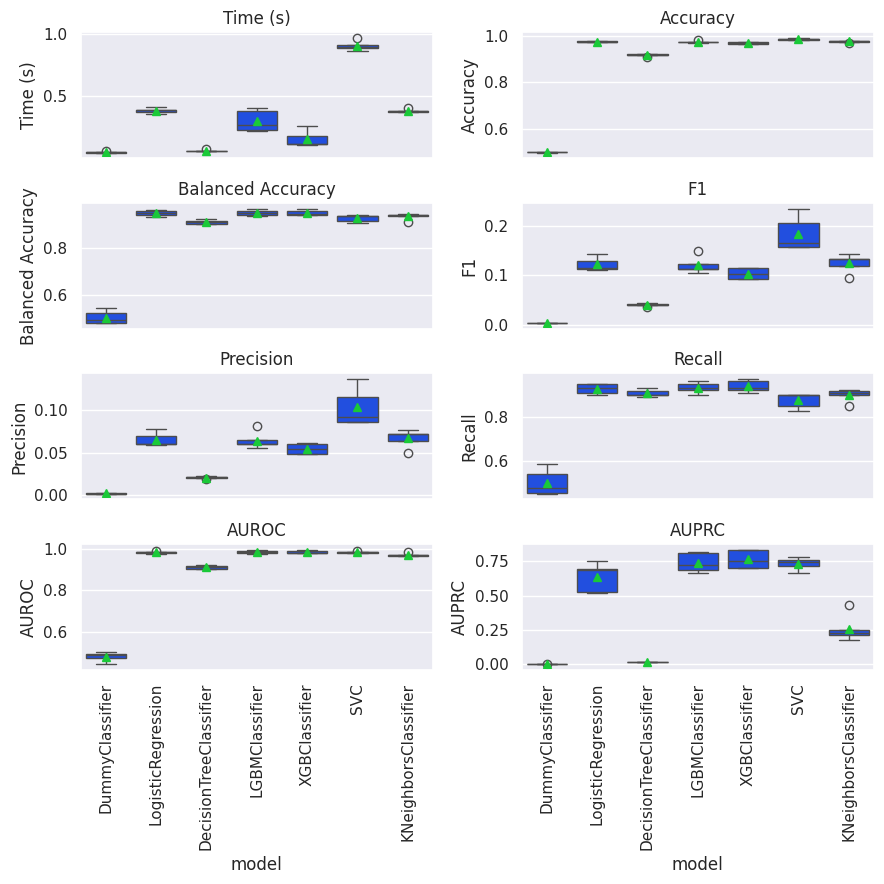

In [12]:
plot_compare_model_metrics(df_results)

In [13]:
classifiers["XGBClassifier"]

{'preprocessor': None,
 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...)}

In [14]:
train_and_validate_classification_model(
    X, y, kf, **classifiers["XGBClassifier"]
)

{'fit_time': array([0.08103538, 0.0595088 , 0.06326294, 0.06821418, 0.08487439]),
 'score_time': array([0.03810525, 0.03414631, 0.03445911, 0.03261852, 0.03831792]),
 'test_accuracy': array([0.97340011, 0.96412425, 0.96505963, 0.96876218, 0.97104217]),
 'test_balanced_accuracy': array([0.9408441 , 0.96165869, 0.94685044, 0.94402496, 0.97037087]),
 'test_f1': array([0.11535969, 0.09265648, 0.0921519 , 0.10196078, 0.11442193]),
 'test_precision': array([0.0615917 , 0.04867944, 0.04848162, 0.0539739 , 0.06079797]),
 'test_recall': array([0.90816327, 0.95918367, 0.92857143, 0.91919192, 0.96969697]),
 'test_roc_auc': array([0.98112091, 0.98930711, 0.98074876, 0.98001275, 0.99678068]),
 'test_average_precision': array([0.7009782 , 0.75225609, 0.83117738, 0.70334119, 0.83342021])}

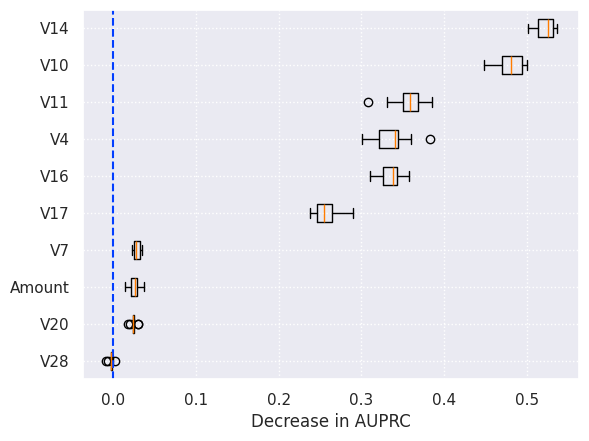

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE, stratify=y
)

clf = classifiers["XGBClassifier"]["classifier"]

clf.fit(X_train, y_train)

perm_imp = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="average_precision",
)

fig, ax = plt.subplots()

ordem = perm_imp.importances_mean.argsort()

ax.boxplot(perm_imp.importances[ordem].T, vert=False, tick_labels=X.columns[ordem])
ax.axvline(x=0, linestyle="--")
ax.set_xlabel("Decrease in AUPRC")
ax.grid(True, linestyle=":")

plt.show()

In [16]:
perm_imp.importances_mean

array([-0.00065706,  0.00841815, -0.01292273,  0.00948247,  0.12923818,
       -0.00640318,  0.00044387,  0.06401596, -0.00093038,  0.00322564,
        0.15350889,  0.25824853,  0.00813373,  0.34193231,  0.04441596,
        0.19174772, -0.00616817,  0.00132857,  0.07950381, -0.00401816,
        0.00060637,  0.00288881,  0.00480166, -0.00037794,  0.04370623,
        0.01764118])

In [17]:
X.columns[perm_imp.importances_mean < 0.01]

Index(['Time', 'V1', 'V2', 'V3', 'V5', 'V6', 'V8', 'V9', 'V12', 'V18', 'V19',
       'V21', 'V23', 'V24', 'V26', 'V27'],
      dtype='str')

In [18]:
X = X.drop(columns=X.columns[perm_imp.importances_mean < 0.01])

X.columns

Index(['V4', 'V7', 'V10', 'V11', 'V14', 'V16', 'V17', 'V20', 'V28', 'Amount'], dtype='str')

In [19]:
train_and_validate_classification_model(
    X, y, kf, **classifiers["XGBClassifier"]
)

{'fit_time': array([1.04375243, 1.04436445, 1.04039288, 1.02980971, 1.08469939]),
 'score_time': array([0.0336802 , 0.03384089, 0.03449655, 0.03388977, 0.03531671]),
 'test_accuracy': array([0.96636527, 0.95701146, 0.95765453, 0.95693351, 0.9608699 ]),
 'test_balanced_accuracy': array([0.92204311, 0.94791093, 0.9431408 , 0.94818068, 0.97031565]),
 'test_f1': array([0.09062171, 0.07698745, 0.07728238, 0.07762938, 0.08810173]),
 'test_precision': array([0.04777778, 0.04013962, 0.04031901, 0.04048759, 0.04612458]),
 'test_recall': array([0.87755102, 0.93877551, 0.92857143, 0.93939394, 0.97979798]),
 'test_roc_auc': array([0.9798086 , 0.98620433, 0.9864694 , 0.98050689, 0.99224265]),
 'test_average_precision': array([0.71475609, 0.77579029, 0.77227332, 0.73074236, 0.77023729])}

In [20]:
param_grid = {
    "clf__max_depth": [3, 6, 10],  # Profundidade da árvore
    # "clf__min_child_weight": [1, 3, 5],  # Peso mínimo de uma folha
    # "clf__gamma": [0, 0.1, 0.3],  # Redução mínima de perda para uma divisão
    "clf__subsample": [0.6, 0.8, 1.0],  # Proporção de amostras usadas para cada árvore
    "clf__colsample_bytree": [0.6, 0.8, 1.0],  # Proporção de features para cada árvore
    # "clf__learning_rate": [0.1, 0.3, 0.5],  # Taxa de aprendizado
    # "clf__n_estimators": [10, 50, 100],  # Número de árvores
    "clf__reg_lambda": [1, 2, 5],  # Regularização L2
    "clf__reg_alpha": [0, 0.5, 1],  # Regularização L1
    # "clf__scale_pos_weight": [1, scale_pos_weight],  # Class weights
}

In [21]:
clf = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = grid_search_cv_classifier(
    clf, param_grid, kf, None, refit_metric="average_precision"
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__colsample_bytree': [0.6, 0.8, ...], 'clf__max_depth': [3, 6, ...], 'clf__reg_alpha': [0, 0.5, ...], 'clf__reg_lambda': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControl

In [22]:
grid_search.fit(X, y)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__colsample_bytree': [0.6, 0.8, ...], 'clf__max_depth': [3, 6, ...], 'clf__reg_alpha': [0, 0.5, ...], 'clf__reg_lambda': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControl

In [23]:
grid_search.best_params_

{'clf__colsample_bytree': 0.6,
 'clf__max_depth': 10,
 'clf__reg_alpha': 0,
 'clf__reg_lambda': 1,
 'clf__subsample': 1.0}

In [24]:
grid_search.best_score_

np.float64(0.7693701635797623)

In [25]:
grid_search.best_estimator_

,steps,"[('sampler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,replacement,False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [26]:
columns_test = [column for column in df_results.columns if column.startswith("test")]
columns_test_mean = ["mean_" + column for column in columns_test]
columns_test_mean

['mean_test_accuracy',
 'mean_test_balanced_accuracy',
 'mean_test_f1',
 'mean_test_precision',
 'mean_test_recall',
 'mean_test_roc_auc',
 'mean_test_average_precision']

In [27]:
for column in columns_test_mean:
    print(f"{column}: {grid_search.cv_results_[column][grid_search.best_index_]}")

mean_test_accuracy: 0.9636292774183491
mean_test_balanced_accuracy: 0.9411754635411913
mean_test_f1: 0.08893392940609486
mean_test_precision: 0.04675028819010232
mean_test_recall: 0.9186353329210473
mean_test_roc_auc: 0.9855712876572337
mean_test_average_precision: 0.7693701635797623


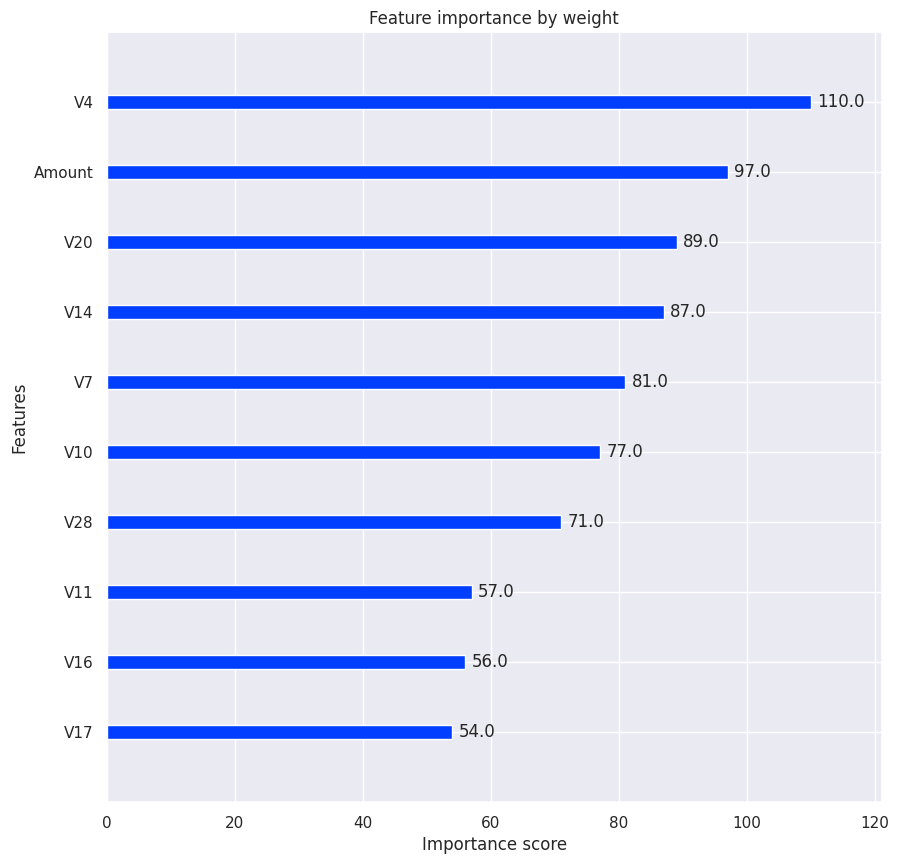

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_importance(
    grid_search.best_estimator_["clf"],
    ax=ax,
    importance_type="weight",
    title="Feature importance by weight"
)

plt.show()

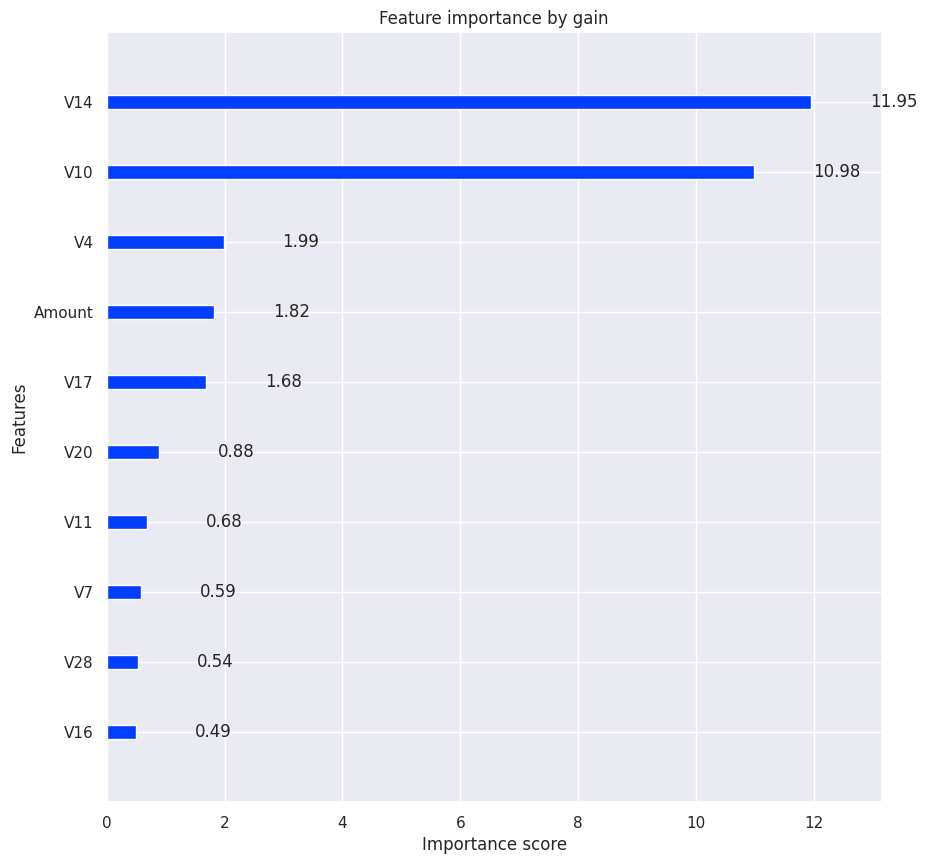

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

plot_importance(
    grid_search.best_estimator_["clf"],
    ax=ax,
    importance_type="gain",
    title="Feature importance by gain",
    values_format="{v:.2f}"
)

plt.show()